In [1]:
import copy

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import spatialdata as sd

/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/squidpy/gr/_utils.py:23: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  CAN_USE_SPARSE_ARRAY = Version(anndata.__vers

In [44]:
sdata = sd.read_zarr("../../data/proseg2.zarr")

/tmp/ipykernel_846983/1967145459.py:1: UserWarning: SpatialData is not stored in the most current format. If you want to use Zarr v3, please write the store to a new location using `sdata.write()`.
  sdata = sd.read_zarr("../../data/proseg2.zarr")
no parent found for <ome_zarr.reader.Label object at 0x7ffc7792c4d0>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffc77e0cc10>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffc774b1e90>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffc774e1850>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffc77c403d0>: None
no parent found for <ome_zarr.reader.Label object at 0x7ffc775b1ed0>: None


In [45]:
bb_xmin = 800
bb_ymin = 1150
bb_w = 200
bb_h = 300
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

INFO     Using 'datashader' backend with 'None' as reduction method to speed up plotting. Depending on the         
         reduction method, the value range of the plot might change. Set method to 'matplotlib' to disable this    
         behaviour.                                                                                                


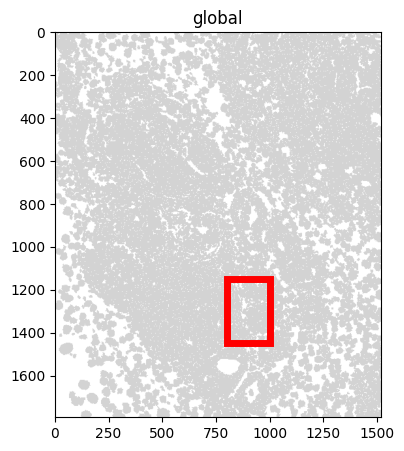

In [46]:
f, ax = plt.subplots(figsize=(5, 5))
sdata.pl.render_shapes("cell_boundaries").pl.show(ax=ax)
rect = patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)

In [47]:
sdata_cropped = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="global",
)

/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


In [33]:
import geopandas as gpd


def _get_center_and_border_shapes(
    sdata: sd.SpatialData,
    shapes_key: str = "cell_boundaries",
    shapes_cell_id_key: str = "cell_id",
    tables_cell_id_key: str = "cell_id",
    erosion_fraction_of_radius: float = 0.3,
) -> tuple[gpd.GeoDataFrame, gpd.GeoDataFrame]:
    """
    Create eroded 'center' and 'border' shapes for each cell by shrinking the
    original cell polygons and taking the difference.

    Parameters
    ----------
    sdata : SpatialData
        SpatialData object with cell boundary polygons in `sdata.shapes[shapes_key]`.
    shapes_key : str, default="cell_boundaries"
        Key in `sdata.shapes` for cell boundary polygons.
    shapes_cell_id_key : str, default="cell_id"
        Column name linking shapes to cell IDs.
    tables_cell_id_key : str, default="cell_id"
        Column in the cell table uniquely identifying each cell.
    erosion_fraction_of_radius : float, default=0.4
        Fraction of the equivalent radius to use as erosion
        Example: 0.4 means erode by 40% of the radius.

    Returns
    -------
    center_gdf : GeoDataFrame
        GeoDataFrame with eroded "center" polygons, indexed or labeled by cell_id.
    border_gdf : GeoDataFrame
        GeoDataFrame with "border" polygons (cell minus center), same indexing.
    """
    cells_gdf = sdata.shapes[shapes_key].copy()

    if shapes_cell_id_key is not None:
        id_key = shapes_cell_id_key
        cells_gdf = cells_gdf.set_index(id_key, drop=True)
    elif cells_gdf.index.name is not None:
        id_key = cells_gdf.index.name
    else:
        id_key = tables_cell_id_key
        cells_gdf.index.name = id_key

    center_records = []
    border_records = []

    areas = cells_gdf.geometry.area
    # Avoid weird issues with tiny/empty shapes
    areas = areas.clip(lower=1e-6)
    radii = np.sqrt(areas / np.pi)
    erosion_dists = radii * erosion_fraction_of_radius

    for _, row in cells_gdf.iterrows():
        cid = row.name
        geom = row.geometry

        # Erode polygon to get center
        d = erosion_dists.loc[cid]
        center_geom = geom.buffer(-d)

        if center_geom.is_empty:
            center_geom = None
            border_geom = geom
        else:
            border_geom = geom.difference(center_geom)

        # check validity safely
        invalid_center = (center_geom is None) or (not center_geom.is_valid)
        invalid_border = (border_geom is None) or (not border_geom.is_valid)

        if invalid_center or invalid_border:
            center_geom = None
            border_geom = None

        center_records.append({id_key: cid, "geometry": center_geom})
        border_records.append({id_key: cid, "geometry": border_geom})

    center_gdf = gpd.GeoDataFrame(center_records, geometry="geometry", crs=cells_gdf.crs)
    border_gdf = gpd.GeoDataFrame(border_records, geometry="geometry", crs=cells_gdf.crs)

    return center_gdf[center_gdf.geometry.notna()], border_gdf[border_gdf.geometry.notna()]

In [34]:
import numpy as np

center_gdf, border_gdf = _get_center_and_border_shapes(sdata_cropped)

In [36]:
print("CENTER geometry types:")
print(center_gdf.geometry.geom_type.value_counts())

print("\nBORDER geometry types:")
print(border_gdf.geometry.geom_type.value_counts())

print("\nExample geometry object type:", type(center_gdf.geometry.iloc[0]))

CENTER geometry types:
Polygon         717
MultiPolygon     20
Name: count, dtype: int64

BORDER geometry types:
MultiPolygon    403
Polygon         334
Name: count, dtype: int64

Example geometry object type: <class 'shapely.geometry.polygon.Polygon'>


In [ ]:
sdata_cropped.shapes["cell_centers"] = sd.models.ShapesModel.parse(center_gdf)
sdata_cropped.shapes["cell_borders"] = sd.models.ShapesModel.parse(border_gdf)

In [29]:
sdata_cropped.shapes["cell_borders"]

,cell_id,geometry
0,17,"MULTIPOLYGON (((841.5 1388, 842.5 1386, 842.5 ..."
1,62,"MULTIPOLYGON (((992.5 1186, 991.5 1185, 991.5 ..."
2,69,"MULTIPOLYGON (((831 1275.5, 834 1275.5, 836 12..."
3,92,"MULTIPOLYGON (((833 1149.5, 832.5 1150, 833.5 ..."
4,133,"MULTIPOLYGON (((993.5 1363, 995 1361.5, 997.5 ..."
...,...,...
740,17750,"MULTIPOLYGON (((846 1218.5, 845.5 1219, 846.5 ..."
741,17763,"MULTIPOLYGON (((900.5 1359, 897 1358.5, 896 13..."
742,17834,"POLYGON ((816 1383.5, 818 1385.5, 818.5 1385, ..."
743,17874,"MULTIPOLYGON (((813.5 1157, 813 1156.5, 810.5 ..."


In [31]:
sdata_cropped.shapes["cell_centers"]

,cell_id,geometry
0,17,"POLYGON ((839.716 1387.56, 840.511 1387.084, 8..."
1,62,"POLYGON ((982.648 1180.174, 982.652 1180.176, ..."
2,69,"POLYGON ((830 1274.297, 830.007 1274.29, 830.1..."
3,92,"POLYGON ((832 1157.2, 834.948 1154.252, 834.08..."
4,133,"POLYGON ((990 1361.613, 990.183 1361.527, 990...."
...,...,...
740,17750,"POLYGON ((854.454 1222.743, 854.634 1222.204, ..."
741,17763,"POLYGON ((900.313 1362.411, 899.686 1359.902, ..."
742,17834,"POLYGON ((801.786 1378.893, 801.791 1379, 801...."
743,17874,"MULTIPOLYGON (((811.445 1158.677, 812.406 1157..."


ValueError: 'vertices' must be 2D with shape (N, 2), but your input has shape (8,)

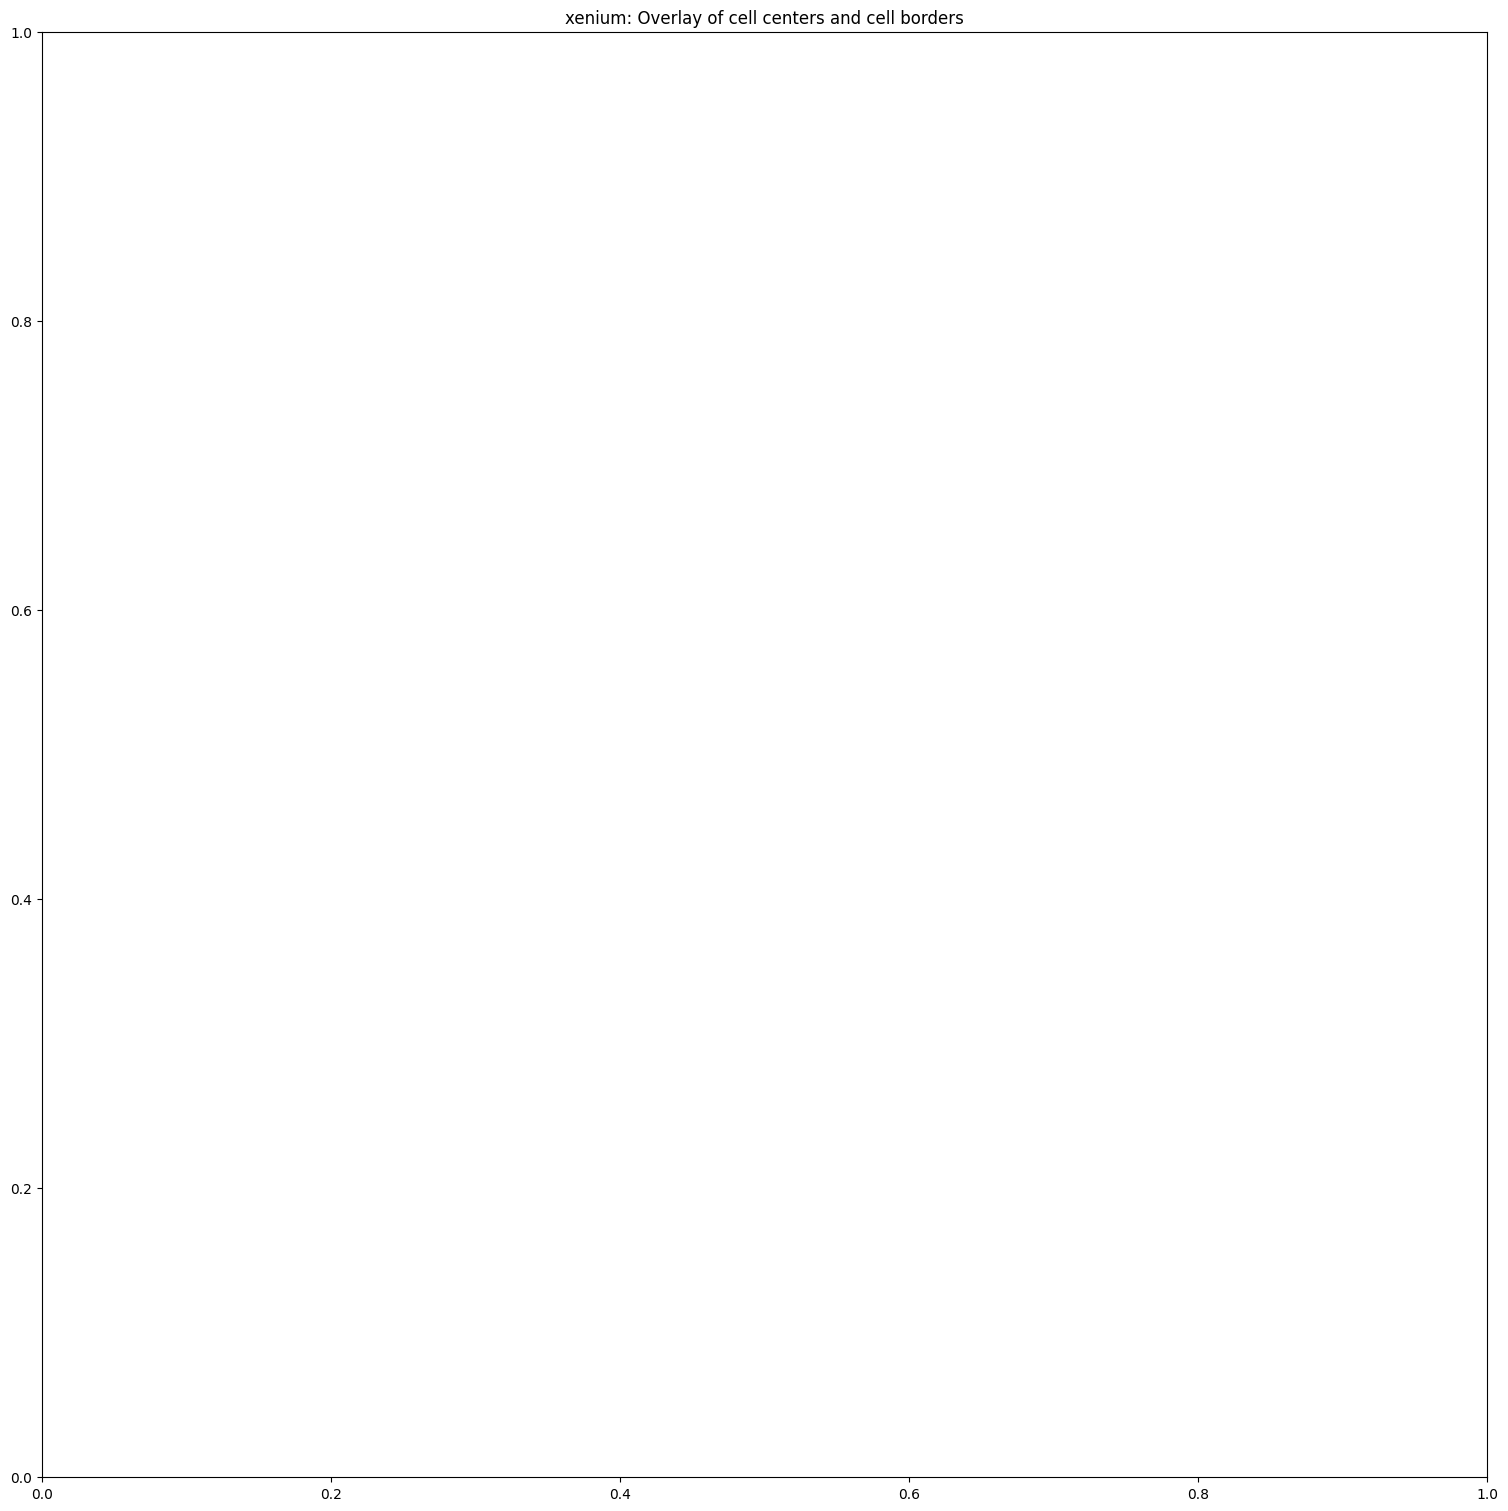

In [30]:
axes = plt.subplots(1, 1, figsize=(15, 15), constrained_layout=True)[1]

sdata_cropped.pl.render_shapes(
    element="cell_centers",
    fill_alpha=0,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="red",
).pl.render_shapes(
    element="cell_borders",
    fill_alpha=0.0,
    outline_alpha=0.8,
    outline_width=0.5,
    outline_color="grey",
).pl.show(ax=axes, title="xenium: Overlay of cell centers and cell borders", colorbar=True)

In [54]:
def _shapes_by_feature_df(
    sdata: sd.SpatialData,
    tables_cell_id_key: str = "cell_id",
    region_key: str = "nucleus_boundaries",
    region_cell_id_key: str = "cell_id",
    points_key: str = "transcripts",
    points_gene_key: str = "feature_name",
) -> pd.DataFrame:
    """
    Aggregate feature counts per region (nucleus or other), converting transcripts to 2D if needed.

    Parameters
    ----------
        sdata : SpatialData
            A `SpatialData` object containing segmented and transcript-assigned spatial
            transcriptomics data (images, tables, points, shapes and optional labels).
        tables_cell_id_key : str, default="cell_id"
            Column in the cell table uniquely identifying each cell.
        region_key : str, default="nucleus_boundaries"
            Key in `sdata.shapes` for defining the regions to aggregate by.
        region_cell_id_key : str default="cell_id"
            Column linking polygons to cell IDs. If `None` is provided, the shape index is used as the cell ID.
        points_key : str, default="transcripts"
            Key in `sdata.points` for spot/transcript-level data.
        points_gene_key : str, default="feature_name"
            Column specifying the gene/feature name for each transcript/spot.

    Returns
    -------
    pandas.DataFrame
        DataFrame indexed by shapes ID, columns = features (genes/proteins), values = counts.
    """

    # perform aggregation
    sdata2 = sdata.aggregate(
        values=points_key,
        by=region_key,
        value_key=points_gene_key,
        agg_func="count",
        deep_copy=False,
    )
    ad = sdata2.tables["table"]

    arr = ad.X.toarray() if hasattr(ad.X, "toarray") else ad.X

    gdf = sdata.shapes[region_key].copy()

    if region_cell_id_key is not None:
        gdf = gdf.set_index(region_cell_id_key, drop=True)
    elif gdf.index.name is None:
        gdf.index.name = tables_cell_id_key

    df_out = pd.DataFrame(arr, index=gdf.index, columns=ad.var_names)
    return df_out

In [ ]:
# import warnings
df_centers = _shapes_by_feature_df(sdata_cropped, region_key="cell_centers")

(array([2.153e+03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 2.871e+03, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.309e+03, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        2.370e+02, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 6.100e+01, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 2.300e+01, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        6.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 3.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 2.000e+0

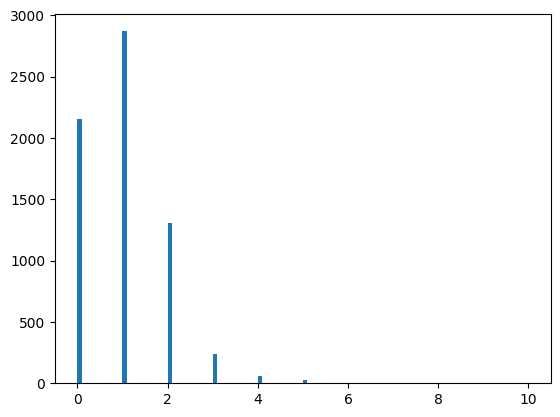

In [ ]:
plt.hist(df_centers.max().values, bins=100, range=(0, 10))

In [ ]:
df_border = _shapes_by_feature_df(sdata_cropped, region_key="cell_borders")

(array([2476.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0., 2562.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0., 1233.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,  284.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,   67.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,   24.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,   10.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    4.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    3.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           3.]),
 array([ 0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,
         1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,
         2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9

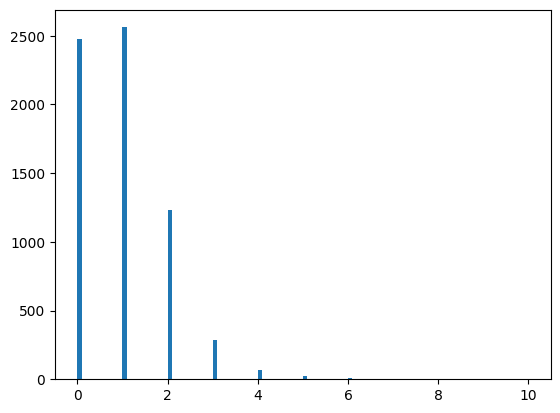

In [ ]:
plt.hist(df_border.max().values, bins=100, range=(0, 10))

`shapes_by_feature` ignores the fact that 3D methods like proseg can have transcripts with same x,y but different z-coordinate assigned to different cell ids. Alternative below:

In [37]:
import geopandas as gpd


def _group_points_by_regions(
    sdata: sd.SpatialData,
    region_key: str,
    points_key: str = "transcripts",
    points_gene_key: str = "feature_name",
    points_x_key: str = "x",
    points_y_key: str = "y",
    points_cell_id_key: str = "cell_id",
    region_cell_id_key: str = "cell_id",
) -> gpd.GeoDataFrame:
    """
    Take transcripts and annotate them with which center / border region
    they fall into, using gpd.sjoin. Returns a GeoDataFrame of points
    with added columns named after the region_cell_id_key.
    """
    pts = sdata.points[points_key].compute()

    pts_gdf = gpd.GeoDataFrame(
        pts,
        geometry=gpd.points_from_xy(pts[points_x_key], pts[points_y_key]),
        crs=sdata.shapes[region_key].crs,  # assume same CRS
    )

    region_gdf = sdata.shapes[region_key].copy()

    region_gdf = region_gdf.rename(columns={region_cell_id_key: "region_id"})
    region_gdf = region_gdf[["region_id", "geometry"]]

    pts_gdf_region = gpd.sjoin(
        pts_gdf,
        region_gdf,
        how="left",
        predicate="within",
    ).drop(columns=["index_right"])

    df_region = (
        pts_gdf_region.loc[
            pts_gdf_region["region_id"] == pts_gdf_region[points_cell_id_key], ["region_id", points_gene_key]
        ]
        .groupby(["region_id", points_gene_key])
        .size()
        .unstack(fill_value=0)
    )
    df_region.index.name = "cell_id"

    return df_region

In [38]:
df_centers = _group_points_by_regions(sdata_cropped, "cell_centers")

/tmp/ipykernel_846983/512391535.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["region_id", points_gene_key])


(array([1.165e+03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 3.135e+03, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 6.380e+02, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.020e+02, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 3.100e+01, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+01, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        6.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 5.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

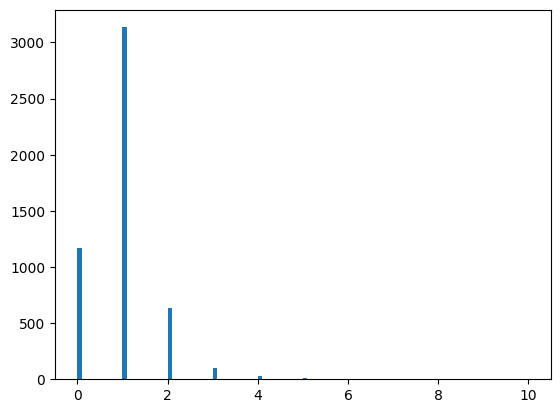

In [39]:
plt.hist(df_centers.max().values, bins=100, range=(0, 10))

In [40]:
df_borders = _group_points_by_regions(sdata_cropped, "cell_borders")

/tmp/ipykernel_846983/512391535.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["region_id", points_gene_key])


(array([2481.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0., 2574.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0., 1220.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,  281.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,   68.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,   22.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,   10.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    4.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    3.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           3.]),
 array([ 0. ,  0.1,  0.2,  0.3,  0.4,  0.5,  0.6,  0.7,  0.8,  0.9,  1. ,
         1.1,  1.2,  1.3,  1.4,  1.5,  1.6,  1.7,  1.8,  1.9,  2. ,  2.1,
         2.2,  2.3,  2.4,  2.5,  2.6,  2.7,  2.8,  2.9

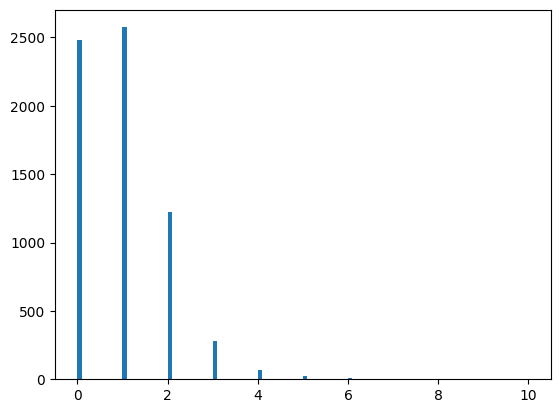

In [87]:
plt.hist(df_borders.max().values, bins=100, range=(0, 10))

In [41]:
from scipy import sparse
from scipy.spatial import cKDTree


def _looks_like_counts(x, n: int = 1000, tol: float = 1e-8) -> bool:
    """Quickly check if data looks like non-negative integer counts."""
    if sparse.issparse(x):
        # Nonzero entries only (zeros are fine for count check)
        arr = x.data
    elif hasattr(x, "values") and not isinstance(x, np.ndarray):
        arr = np.asarray(x.values).ravel()
    else:
        arr = np.asarray(x).ravel()

    if arr.size == 0:
        return False
    if np.issubdtype(arr.dtype, np.integer):
        return True

    samp = arr if arr.size <= n else np.random.choice(arr, n, replace=False)
    return np.all(samp >= 0) and np.allclose(samp, np.round(samp), atol=tol)


def _compute_ncvs_within_radius(
    sdata: sd.SpatialData,
    tables_key: str = "table",
    tables_cell_id_key: str = "cell_id",
    shapes_key: str = "cell_boundaries",
    shapes_cell_id_key: str = "cell_id",
    radius_factor: float = 2.0,
) -> pd.DataFrame:
    """
    Compute neighborhood composition vectors (NCVs) as the average gene expression
    of neighboring cells within a user-defined distance.

    Parameters
    ----------
    sdata : SpatialData
        SpatialData object with cell shapes and cell-level table.
    tables_key : str, default="table"
        Key in `sdata.tables` for the cell-level AnnData.
    tables_cell_id_key : str, default="cell_id"
        Column in the cell table uniquely identifying each cell.
    shapes_key : str, default="cell_boundaries"
        Key in `sdata.shapes` for cell boundary polygons.
    shapes_cell_id_key : str, default="cell_id"
        Column in the shapes GeoDataFrame linking polygons to cell IDs.
    radius_factor : float, default=2.0
        Neighborhood radius factor in the same coordinate units as the shapes.

    Returns
    -------
    pandas.DataFrame
        DataFrame of NCVs: index = cell IDs, columns = genes, values = average
        expression of neighbors within `radius` (excluding the focal cell).
    """
    # Get centroids for each cell shape
    cells_gdf = sdata.shapes[shapes_key].copy()
    if shapes_cell_id_key is not None:
        id_key = shapes_cell_id_key
        cells_gdf = cells_gdf.set_index(id_key, drop=True)
    elif cells_gdf.index.name is not None:
        id_key = cells_gdf.index.name
    else:
        id_key = tables_cell_id_key
        cells_gdf.index.name = id_key

    tbl = sdata.tables[tables_key]
    ad = tbl
    X = ad.X

    if _looks_like_counts(X):
        arr = X.toarray() if hasattr(X, "toarray") else X
    elif "raw" not in tbl.layers:
        raise ValueError(
            f"'raw' layer does not exist in sdata.tables['{tables_key}'], "
            "and the main matrix does not look like counts."
        )
    else:
        raw = tbl.layers["raw"]
        arr = raw.toarray() if hasattr(raw, "toarray") else raw

    mask = ad.obs[tables_cell_id_key].isin(cells_gdf.index)
    expr_cells = pd.DataFrame(
        arr[mask, :],
        index=ad.obs[tables_cell_id_key][mask],
        columns=ad.var.index,
    )

    # Align order between shapes and table: we assume one shape per cell
    cells_gdf = cells_gdf.loc[expr_cells.index]
    centroids = cells_gdf.geometry.centroid
    coords = np.vstack([centroids.x.values, centroids.y.values]).T

    areas = cells_gdf.geometry.area
    # Avoid weird issues with tiny/empty shapes
    areas = areas.clip(lower=1e-6)
    radii = np.sqrt(areas / np.pi)
    radii.reset_index(inplace=True, drop=True)

    tree = cKDTree(coords)

    n_cells = expr_cells.shape[0]
    genes = expr_cells.columns
    ncv_arr = np.zeros_like(expr_cells.values, dtype=float)

    for i in range(n_cells):
        # Query neighbors within radius (including itself)
        idxs = tree.query_ball_point(coords[i], r=radii[i] * radius_factor)
        # Remove self
        idxs = [j for j in idxs if j != i]
        if len(idxs) == 0:
            # no neighbors in radius: define NCV as zeros or NaN
            ncv_arr[i, :] = 0.0
        else:
            ncv_arr[i, :] = expr_cells.values[idxs, :].mean(axis=0)

    expr_ncv = pd.DataFrame(ncv_arr, index=expr_cells.index, columns=genes)
    return expr_ncv

In [42]:
expr_ncv = _compute_ncvs_within_radius(sdata_cropped)

(array([6.440e+02, 3.000e+01, 1.390e+02, 2.810e+02, 2.000e+00, 8.510e+02,
        5.100e+01, 9.000e+00, 0.000e+00, 0.000e+00, 2.367e+03, 0.000e+00,
        3.000e+00, 2.100e+01, 0.000e+00, 6.900e+01, 9.000e+00, 2.000e+00,
        0.000e+00, 0.000e+00, 4.380e+02, 0.000e+00, 1.000e+00, 1.000e+00,
        0.000e+00, 1.800e+01, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        7.800e+01, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 6.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 3.400e+01, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.600e+01, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        5.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 5.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 4.000e+0

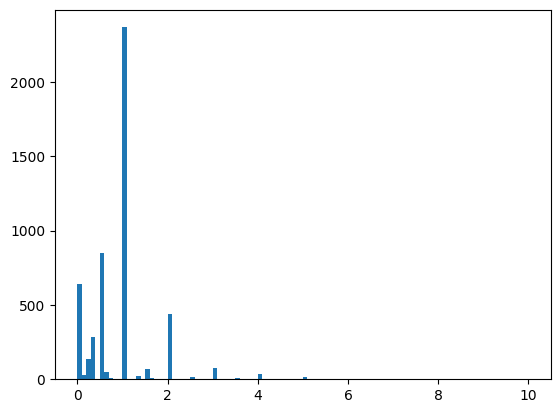

In [43]:
plt.hist(expr_ncv.max().values, bins=100, range=(0, 10))

In [48]:
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics.pairwise import cosine_similarity


def merge_into_obs(
    sdata, tables_key, df_to_merge: pd.DataFrame, tables_cell_id_key: str, df_cell_id_key: str, fillna_cols=None
):
    """
    Left-join df_to_merge into sdata.tables[tables_key].obs without resetting the index
    and without creating duplicate key columns.

    - Preserves obs index
    - Uses obs[tables_cell_id_key] as the join key unless df_cell_id_key already exists in obs
    - Drops overlapping columns on the right (or overwrites if overwrite=True)
    """

    obs = sdata.tables[tables_key].obs

    # Choose the column on the left to join on:
    # If the right's key already exists in obs, prefer that (avoids redundant columns)
    left_on_key = (
        df_cell_id_key if (df_cell_id_key == obs.index.name or df_cell_id_key in obs.columns) else tables_cell_id_key
    )

    # Build right indexed by the join key
    if df_to_merge.index.name != df_cell_id_key:
        right = df_to_merge.set_index(df_cell_id_key, drop=True)
    else:
        right = df_to_merge

    # Decide which columns from right to bring over
    right_cols = list(right.columns)
    overlapping_cols = [c for c in right_cols if c in obs.columns and c != df_cell_id_key]
    if overlapping_cols:
        obs = obs.drop(columns=overlapping_cols)

    # Perform a left join while preserving the left index.
    # Two cases: join using a left column (on=...) or directly on the index.
    if obs.index.name == left_on_key:
        # Index-on-index join (fast, preserves index)
        joined = obs.join(right, how="left")
    else:
        joined = obs.join(right, on=left_on_key, how="left")

    # Fill NAs if requested
    if fillna_cols:
        for c in fillna_cols:
            if c in joined.columns:
                joined[c] = joined[c].fillna(0)

    # Assign back (no intermediate index reset happened)
    sdata.tables[tables_key].obs = joined


def _norm_log_df(df: pd.DataFrame, scale: float = 1e4) -> pd.DataFrame:
    # row-wise library size normalization + log1p
    sums = df.sum(axis=1).replace(0, np.nan)
    df_norm = df.div(sums, axis=0) * scale
    return np.log1p(df_norm).fillna(0.0)


def compute_border_similarity_contamination(
    sdata: sd.SpatialData,
    tables_key: str = "table",
    tables_cell_id_key: str = "cell_id",
    shapes_key: str = "cell_boundaries",
    shapes_cell_id_key: str = "cell_id",
    points_key: str = "transcripts",
    points_cell_id_key: str = "cell_id",
    points_x_key: str = "x",
    points_y_key: str = "y",
    points_gene_key: str = "feature_name",
    erosion_fraction_of_radius: float | None = 0.2,
    radius_factor: float = 2.0,
    metric: str = "cosine_sim",
    inplace: bool = True,
) -> pd.DataFrame:
    """
    For each cell, compute a border similarity contamination score by (1) comparing
    gene expression in an eroded interior ("center") and a thin outer shell
    ("border"), and (2) comparing the border with the neighborhood
    composition vector (NCV).

    Specifically, the function:
      1. Erodes each cell polygon to obtain a center region.
      2. Defines the border region as the set difference between the full cell
         and its eroded center.
      3. Computes gene expression profiles for center and border.
      4. Computes the correlation between center and border expression.
      5. Computes the correlation between border expression and the
         NCV expression profile of the same cell.

    Parameters
    ----------
    sdata : SpatialData
        A `SpatialData` object containing segmented and transcript-assigned
        spatial transcriptomics data (tables, points, shapes, etc.).
    tables_key : str, default="table"
        Key in `sdata.tables` for the cell-level metadata table.
    tables_cell_id_key : str, default="cell_id"
        Column in the cell table uniquely identifying each cell.
    shapes_key : str, default="cell_boundaries"
        Key in `sdata.shapes` for cell boundary polygons.
    shapes_cell_id_key : str, default="cell_id"
        Column in `sdata.shapes[shapes_key]` linking polygons to cell IDs.
        If `None`, the shape index is used as the cell ID.
    points_key : str, default="transcripts"
        Key in `sdata.points` for spot/transcript-level data.
    points_cell_id_key : str, default="cell_id"
        Column in the points table linking each transcript/spot to a cell.
    points_x_key : str, default="x"
        Column for the x-coordinate of each transcript/spot.
    points_y_key : str, default="y"
        Column for the y-coordinate of each transcript/spot.
    points_gene_key : str, default="feature_name"
        Column specifying the gene/feature name for each transcript/spot.
    radius_factor : float, default=2.0
        Neighborhood radius factor in the same coordinate units as the shapes.
    erosion_fraction_of_radius : float or None, default=0.4
        Fraction of the equivalent radius to use as erosion
        Example: 0.4 means erode by 40% of the radius.
    metric : str, default="pearson"
        Correlation metric to use ("pearson", "spearman", "cosine_sim" currently supported).
    inplace : bool, optional
        Whether to add the results to `sdata.tables[tables_key].obs`. Default is True.

    Returns
    -------
    pandas.DataFrame
        DataFrame with columns:
            - `tables_cell_id_key`: identifier of each cell,
            - `corr_center_border`: correlation between center and border expression,
            - `corr_border_ncv`: correlation between border and NCV expression
    """

    center_gdf, border_gdf = _get_center_and_border_shapes(
        sdata=sdata,
        shapes_key=shapes_key,
        shapes_cell_id_key=shapes_cell_id_key,
        tables_cell_id_key=tables_cell_id_key,
        erosion_fraction_of_radius=erosion_fraction_of_radius,
    )

    sdata.shapes["cell_centers"] = sd.models.ShapesModel.parse(center_gdf, transformations=None)
    sdata.shapes["cell_borders"] = sd.models.ShapesModel.parse(border_gdf, transformations=None)

    cell_shape_transformation = sd.transformations.get_transformation(sdata.shapes[shapes_key])
    sd.transformations.set_transformation(sdata.shapes["cell_centers"], cell_shape_transformation)
    sd.transformations.set_transformation(sdata.shapes["cell_borders"], cell_shape_transformation)

    expr_center = _group_points_by_regions(
        sdata=sdata,
        region_key="cell_centers",
        points_key=points_key,
        points_gene_key=points_gene_key,
        points_x_key=points_x_key,
        points_y_key=points_y_key,
        points_cell_id_key=points_cell_id_key,
        region_cell_id_key=shapes_cell_id_key,
    )

    expr_border = _group_points_by_regions(
        sdata=sdata,
        region_key="cell_borders",
        points_key=points_key,
        points_gene_key=points_gene_key,
        points_x_key=points_x_key,
        points_y_key=points_y_key,
        points_cell_id_key=points_cell_id_key,
        region_cell_id_key=shapes_cell_id_key,
    )

    expr_ncv = _compute_ncvs_within_radius(
        sdata=sdata,
        tables_key=tables_key,
        tables_cell_id_key=tables_cell_id_key,
        shapes_key=shapes_key,
        shapes_cell_id_key=shapes_cell_id_key,
        radius_factor=radius_factor,
    )

    # Align dataframe columns
    common_genes = expr_center.columns.intersection(expr_border.columns)
    common_genes = common_genes.intersection(expr_ncv.columns)

    expr_center = expr_center[common_genes]
    expr_border = expr_border[common_genes]
    expr_ncv = expr_ncv[common_genes]

    # Align dataframe rows- these might not match
    # expr_ncv computed based on table and expr_center/border based on shapes
    common_cells = expr_center.index.intersection(expr_border.index)
    common_cells = common_cells.intersection(expr_ncv.index)

    expr_center = expr_center.loc[common_cells]
    expr_border = expr_border.loc[common_cells]
    expr_ncv = expr_ncv.loc[common_cells]

    expr_center_raw = expr_center
    expr_border_raw = expr_border
    expr_ncv_raw = expr_ncv

    expr_center = _norm_log_df(expr_center_raw)
    expr_border = _norm_log_df(expr_border_raw)
    expr_ncv = _norm_log_df(expr_ncv_raw)

    id_key = expr_center.index.name

    rows = []

    for cid in expr_center.index:
        x_center = expr_center.loc[cid].to_numpy().ravel()
        x_border = expr_border.loc[cid].to_numpy().ravel()
        x_ncv = expr_ncv.loc[cid].to_numpy().ravel()

        x_center_raw = expr_center_raw.loc[cid].to_numpy().ravel()
        x_border_raw = expr_border_raw.loc[cid].to_numpy().ravel()
        x_ncv_raw = expr_ncv_raw.loc[cid].to_numpy().ravel()

        # Filter out genes that are zero in all three regions
        mask = (x_center_raw != 0) | (x_border_raw != 0) | (x_ncv_raw != 0)
        x_center = x_center[mask]
        x_border = x_border[mask]
        x_ncv = x_ncv[mask]

        corr_center_border = np.nan
        corr_border_ncv = np.nan
        corr_ncv_vs_center = np.nan

        if metric not in ["pearson", "spearman", "cosine_sim"]:
            raise ValueError(f"Metric {metric} not supported")

        # center–border similarity
        if not (np.all(x_center == 0) or np.all(x_border == 0)):
            if metric == "pearson":
                corr_center_border, _ = pearsonr(x_center, x_border)
            elif metric == "spearman":
                corr_center_border, _ = spearmanr(x_center, x_border)
            elif metric == "cosine_sim":
                corr_center_border = cosine_similarity(x_center.reshape(1, -1), x_border.reshape(1, -1))[0, 0]

        # border–NCV similarity
        if not (np.all(x_border == 0) or np.all(x_ncv == 0)):
            if metric == "pearson":
                corr_border_ncv, _ = pearsonr(x_border, x_ncv)
            elif metric == "spearman":
                corr_border_ncv, _ = spearmanr(x_border, x_ncv)
            elif metric == "cosine_sim":
                corr_border_ncv = cosine_similarity(x_border.reshape(1, -1), x_ncv.reshape(1, -1))[0, 0]

        # ratio: border–NCV vs center–border
        if (
            not np.isnan(corr_center_border)
            and not np.isnan(corr_border_ncv)
            and not np.isclose(corr_center_border, 0.0)
        ):
            corr_ncv_vs_center = corr_border_ncv / corr_center_border

            rows.append(
                {
                    id_key: cid,
                    "corr_center_border": corr_center_border,
                    "corr_border_ncv": corr_border_ncv,
                    "corr_ncv_vs_center": corr_ncv_vs_center,
                }
            )

    corr_df = pd.DataFrame(rows)

    if inplace:
        merge_into_obs(
            sdata=sdata,
            tables_key=tables_key,
            df_to_merge=corr_df,
            tables_cell_id_key=tables_cell_id_key,
            df_cell_id_key=id_key,
        )

    return corr_df

In [49]:
compute_border_similarity_contamination(sdata_cropped)

/tmp/ipykernel_846983/512391535.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["region_id", points_gene_key])
/tmp/ipykernel_846983/512391535.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["region_id", points_gene_key])


,cell_id,corr_center_border,corr_border_ncv,corr_ncv_vs_center
0,17.0,0.155362,0.071018,0.457112
1,62.0,0.083752,0.097371,1.162616
2,69.0,0.083640,0.089063,1.064829
3,133.0,0.197070,0.274111,1.390935
4,200.0,0.153371,0.168230,1.096885
...,...,...,...,...
420,17238.0,0.102249,0.073149,0.715405
421,17371.0,0.064085,0.129862,2.026405
422,17734.0,0.086967,0.000000,0.000000
423,17750.0,0.188982,0.149064,0.788771


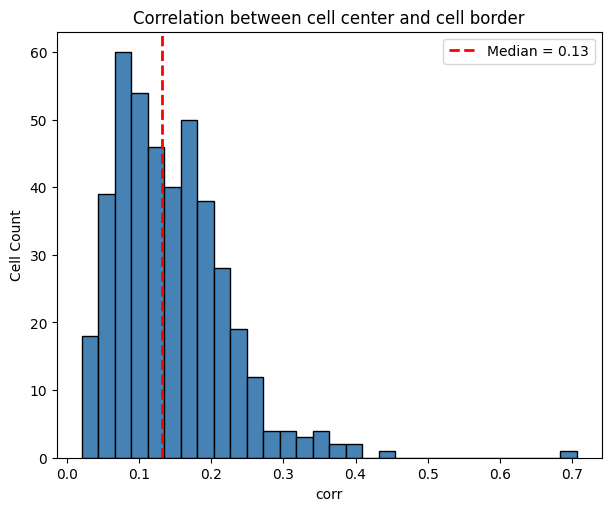

In [50]:
import matplotlib.pyplot as plt

# Prepare IoU values
corr = sdata_cropped["table"].obs["corr_center_border"].dropna()
median_iou = np.median(corr)

# Set up figure with histogram
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

# Plot histogram
ax.hist(corr, bins=30, color="steelblue", edgecolor="black")

# Add median line
ax.axvline(
    median_iou,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_iou:.2f}",
)

# Decorate
ax.set_title("Correlation between cell center and cell border")
ax.set_xlabel("corr")
ax.set_ylabel("Cell Count")
ax.legend()

plt.show()

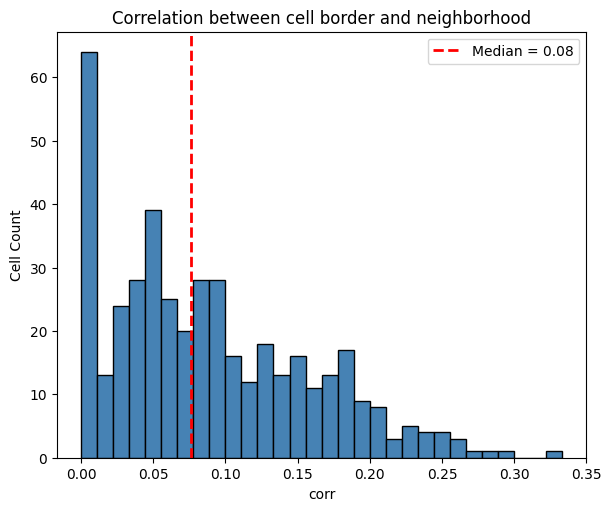

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare IoU values
corr = sdata_cropped["table"].obs["corr_border_ncv"].dropna()
median_iou = np.median(corr)

# Set up figure with histogram
fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

# Plot histogram
ax.hist(corr, bins=30, color="steelblue", edgecolor="black")

# Add median line
ax.axvline(
    median_iou,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_iou:.2f}",
)

# Decorate
ax.set_title("Correlation between cell border and neighborhood")
ax.set_xlabel("corr")
ax.set_ylabel("Cell Count")
ax.legend()

plt.show()

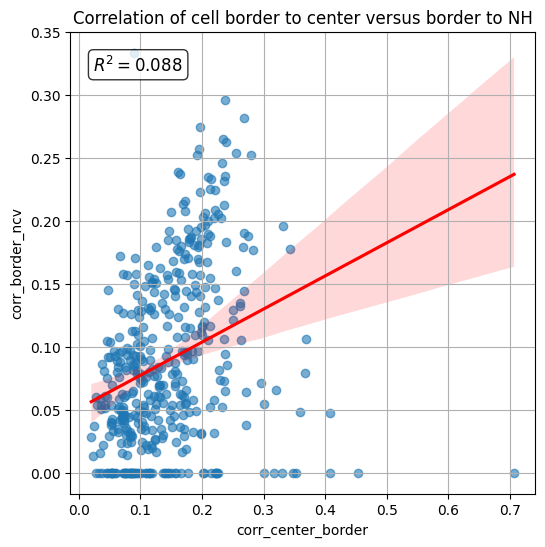

In [52]:
from scipy.stats import linregress

obs = sdata_cropped["table"].obs
# Extract the relevant columns, excluding NaNs
df = obs[["corr_center_border", "corr_border_ncv"]].dropna()

# Compute regression metrics
slope, intercept, r_value, p_value, std_err = linregress(df["corr_center_border"], df["corr_border_ncv"])
r_squared = r_value**2

# Create the plot
plt.figure(figsize=(6, 6))
ax = sns.regplot(
    data=df,
    x="corr_center_border",
    y="corr_border_ncv",
    scatter_kws={"alpha": 0.6},
    line_kws={"color": "red"},
    ci=95,
)

# Overlay the R² value
ax.text(
    0.05,
    0.95,
    f"$R^2 = {r_squared:.3f}$",
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
)

ax.set_xlabel("corr_center_border")
ax.set_ylabel("corr_border_ncv")
ax.set_title("Correlation of cell border to center versus border to NH")
ax.grid(True)

plt.show()

In [53]:
# filter out entries with NaN correlation for plotting
sdata_plot = copy.deepcopy(sdata_cropped)
sdata_plot["table"] = sdata_plot["table"][
    (sdata_plot["table"].obs["corr_center_border"].notna() & sdata_plot["table"].obs["corr_border_ncv"].notna())
]

/tmp/ipykernel_846983/4198321451.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sdata_plot.tables["table"].obs["region"] = "cell_boundaries"
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata/_core/spatialdata.py:482: UserWarning: Converting `region_key: region` to categorical dtype.
  convert_region_column_to_categorical(table)


INFO     input has more than 103 categories. Uniform 'grey' color will be used for all categories.                 


/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/home/lazic/.local/share/uv/python/cpython-3.11.13-linux-x86_64-gnu/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/utils.py:872: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_mapping)
/home/lazic/.venvs/segtraq_py311/lib/python3.11/site-packages/spatialdata_plot/pl/render.py:821: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _c

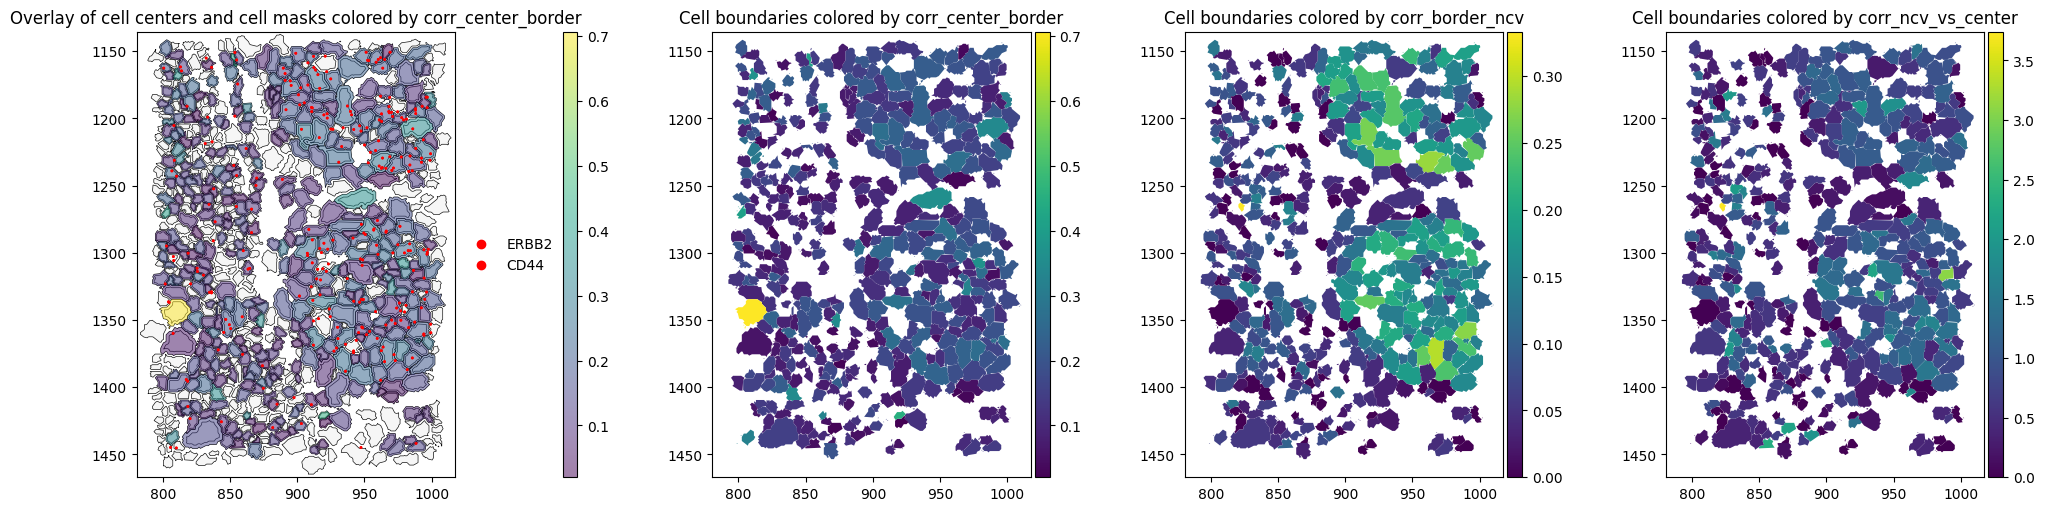

In [54]:
# link annotations with cell boundaries
sdata_plot.tables["table"].obs["region"] = "cell_boundaries"
sdata_plot.set_table_annotates_spatialelement("table", region="cell_boundaries")

axes = plt.subplots(1, 4, figsize=(20, 5), constrained_layout=True)[1].flatten()

sdata_plot.pl.render_shapes(
    element="cell_centers",
    fill_alpha=0.2,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_shapes(
    element="cell_boundaries",
    color="corr_center_border",
    cmap="viridis",
    fill_alpha=0.5,
    outline_alpha=1.0,
    outline_width=0.5,
    outline_color="black",
).pl.render_points(
    "transcripts",
    color="feature_name",
    groups=["ERBB2", "CD44", "PTPRC"],
    palette=["red", "red", "red"],
).pl.show(
    ax=axes[0],
    title="Overlay of cell centers and cell masks colored by corr_center_border",
    colorbar=True,
    figsize=(6, 6),
)


sdata_plot.pl.render_shapes("cell_boundaries", color="corr_center_border").pl.show(
    ax=axes[1], title="Cell boundaries colored by corr_center_border", coordinate_systems="global"
)

sdata_plot.pl.render_shapes("cell_boundaries", color="corr_border_ncv").pl.show(
    ax=axes[2], title="Cell boundaries colored by corr_border_ncv", coordinate_systems="global"
)

sdata_plot.pl.render_shapes("cell_boundaries", color="corr_ncv_vs_center").pl.show(
    ax=axes[3], title="Cell boundaries colored by corr_ncv_vs_center", coordinate_systems="global"
)